## **Modelo competidor no Desafio de Previsão de Sucesso de Startups**

- Objetivo: Prever se uma startup terá sucesso ou não.

#### **Sumário**

1. Exploração de dados
2. Pré-Processamento
3. Codificação de variáveis categóricas

#### **1. Exploração de dados**

&nbsp;&nbsp;&nbsp;&nbsp;Aqui é feita a exploração inicial dos dados, visando compreender os dados recebidos, é o primeiro passo para a correta manipulação e utilização dos dados

In [31]:
import pandas as pd

- Primeira visualização do dataframe de treino com raw data:

In [14]:
df_train = pd.read_csv("./train.csv")
df_train.head(40)

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,labels
0,719,10.42,13.09,8.98,12.72,4,3,4087500,3,1,...,0,0,1,1,0,0,0,0,1.0000,0
1,429,3.79,3.79,NaN,NaN,21,1,45000000,0,0,...,0,0,0,0,0,1,0,0,1.0000,1
2,178,0.71,2.28,1.95,2.28,5,2,5200000,2,1,...,0,1,1,0,1,0,0,0,1.0000,0
3,197,3.00,5.00,9.62,10.39,16,2,14500000,2,0,...,0,0,0,1,0,1,0,0,2.0000,1
4,444,0.66,5.88,6.21,8.61,29,5,70000000,4,1,...,0,0,0,0,1,1,1,1,2.8000,1
5,67,1.09,1.09,NaN,NaN,5,1,20500000,0,0,...,0,0,1,0,0,0,0,0,4.0000,0
6,505,0.65,0.65,NaN,NaN,3,1,900000,0,1,...,0,0,0,0,1,0,0,0,1.0000,0
7,410,0.34,5.22,3.00,6.03,5,4,48730000,3,0,...,0,0,1,0,1,1,1,0,3.0000,1
8,284,0.00,0.00,0.74,0.74,2,1,50000,1,1,...,0,0,0,1,0,0,0,0,2.0000,0
9,252,0.08,4.33,3.66,5.61,12,7,88651133,5,0,...,0,0,1,1,1,1,1,1,3.1667,1


In [ ]:
df_train.dtypes

id                            int64
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX                         int64
is_otherstate                 int64
category_code                object
is_software                   int64
is_web                        int64
is_mobile                     int64
is_enterprise                 int64
is_advertising                int64
is_gamesvideo                 int64
is_ecommerce                  int64
is_biotech                    int64
is_consulting                 int64
is_othercategory              int64
has_VC                        int64
has_angel                     int64
has_roundA                  

- Observações:

>as colunas "age_first_funding_year", "age_last_funding_year", "age_first_milestone_year" e "age_last_milestone_year" tem dados faltantes.

- É necessário fazer um pré-processamento dos dados

- Primeira visualização do dataframe de teste com raw data:

In [ ]:
df_test = pd.read_csv("./test.csv")
df_test.head(20)

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_biotech,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants
0,70,1.33,3.02,3.02,3.34,9,3,11489687,2,1,...,0,0,0,0,1,1,1,0,0,3.3333
1,23,5.49,5.49,0.00,0.00,1,1,3170000,1,1,...,0,0,0,0,0,1,0,0,0,2.0000
2,389,5.84,8.22,NaN,NaN,4,3,47218498,0,1,...,0,0,1,1,0,0,0,1,1,3.3333
3,872,6.30,6.30,6.00,6.00,9,1,15000000,1,1,...,1,0,0,0,0,0,0,0,0,3.0000
4,920,7.25,9.23,6.00,6.00,1,3,52000000,1,0,...,0,0,1,1,0,0,1,0,0,2.6667
5,690,0.00,1.50,1.58,3.17,7,2,1400000,2,0,...,0,0,1,0,1,1,0,0,0,6.0000
6,588,0.15,0.15,NaN,NaN,4,1,600000,0,0,...,0,0,0,0,1,0,0,0,0,2.0000
7,144,1.92,1.92,2.00,2.00,4,1,4410000,1,1,...,0,0,0,0,0,1,0,0,0,1.0000
8,875,0.17,3.78,3.84,6.12,6,2,626096,3,0,...,0,0,0,1,0,1,0,0,0,1.0000
9,900,1.30,2.47,0.00,2.47,3,2,1800000,2,0,...,0,0,1,1,1,0,0,0,0,5.0000


- Observações:

>as colunas "age_first_funding_year", "age_last_funding_year", "age_first_milestone_year" e "age_last_milestone_year" tem dados faltantes.

- Assim como o df de treino, o de teste precisa de um pré-processamento dos dados.

**2. Pré-Processamento**

In [40]:
import numpy as np
import matplotlib.pyplot as plt 

- Para o tratamento dos valores núlos, verifiquei se haveria algum problema em substituir por 0. Vendo a tabela e comportamento dos demais dados, é possivel oberservar que é existem outras linhas zeradas naturalmente, então compreende-se que não é um problema substituir as colunas núlas por 0.

Preenchendo os valores núlos por 0 na tabela de treino:

In [21]:
#Preenchendo os valores núlos por 0 na tabela de treino.
df_train = df_train.fillna(0)
df_train.head()

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,labels
0,719,10.42,13.09,8.98,12.72,4,3,4087500,3,1,...,0,0,1,1,0,0,0,0,1.0,0
1,429,3.79,3.79,0.00,0.00,21,1,45000000,0,0,...,0,0,0,0,0,1,0,0,1.0,1
2,178,0.71,2.28,1.95,2.28,5,2,5200000,2,1,...,0,1,1,0,1,0,0,0,1.0,0
3,197,3.00,5.00,9.62,10.39,16,2,14500000,2,0,...,0,0,0,1,0,1,0,0,2.0,1
4,444,0.66,5.88,6.21,8.61,29,5,70000000,4,1,...,0,0,0,0,1,1,1,1,2.8,1


Preenchendo os valores núlos por 0 na tabela de teste:

In [20]:
#Preenchendo os valores núlos por 0 na tabela de teste.
df_test = df_test.fillna(0)
df_test.head()

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_biotech,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants
0,70,1.33,3.02,3.02,3.34,9,3,11489687,2,1,...,0,0,0,0,1,1,1,0,0,3.3333
1,23,5.49,5.49,0.00,0.00,1,1,3170000,1,1,...,0,0,0,0,0,1,0,0,0,2.0000
2,389,5.84,8.22,0.00,0.00,4,3,47218498,0,1,...,0,0,1,1,0,0,0,1,1,3.3333
3,872,6.30,6.30,6.00,6.00,9,1,15000000,1,1,...,1,0,0,0,0,0,0,0,0,3.0000
4,920,7.25,9.23,6.00,6.00,1,3,52000000,1,0,...,0,0,1,1,0,0,1,0,0,2.6667


**3. Codificação de variáveis categóricas:**

Para buscar colunas categóricas, veja o tipo dos dados presente nas tabelas:


In [23]:
df_train.dtypes

id                            int64
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX                         int64
is_otherstate                 int64
category_code                object
is_software                   int64
is_web                        int64
is_mobile                     int64
is_enterprise                 int64
is_advertising                int64
is_gamesvideo                 int64
is_ecommerce                  int64
is_biotech                    int64
is_consulting                 int64
is_othercategory              int64
has_VC                        int64
has_angel                     int64
has_roundA                  

In [24]:
df_test.dtypes

id                            int64
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX                         int64
is_otherstate                 int64
category_code                object
is_software                   int64
is_web                        int64
is_mobile                     int64
is_enterprise                 int64
is_advertising                int64
is_gamesvideo                 int64
is_ecommerce                  int64
is_biotech                    int64
is_consulting                 int64
is_othercategory              int64
has_VC                        int64
has_angel                     int64
has_roundA                  

- Oberservação:

>Em ambas as tabelas a coluna category_code são do tipo object e precisam ser transformadas

- Verificando índices e frequencias para a coluna category_code

In [ ]:
freq_category_code = df_train["category_code"].value_counts()
print(freq_category_code)

[105  97  65  53  45  37  25  24  20  18  18  15  14  14  12  10   9   9
   7   7   7   6   5   4   4   3   2   2   2   2   2   1   1   1]


([<matplotlib.patches.Wedge at 0x28128b7dbe0>,
 [Text(0.9596802626103041, 0.5376000312092791, 'software'),
  Text(0.0855050572345573, 1.0966717308234561, 'web'),
  Text(-0.7170332267861074, 0.8341842432488777, 'mobile'),
  Text(-1.0550302919533616, 0.31130544977691055, 'enterprise'),
  Text(-1.0802747018600978, -0.2073802510391889, 'advertising'),
  Text(-0.9149880411960434, -0.6105709495777111, 'games_video'),
  Text(-0.6923913776375943, -0.8547480214502486, 'biotech'),
  Text(-0.47106656538763225, -0.9940303269890208, 'semiconductor'),
  Text(-0.24924136979916126, -1.0713910301942227, 'ecommerce'),
  Text(-0.04812986311223383, -1.0989465484166179, 'hardware'),
  Text(0.1440205526066291, -1.0905311001649065, 'network_hosting'),
  Text(0.31643223939382625, -1.0535039809474895, 'public_relations'),
  Text(0.46137599895169057, -0.9985650642753982, 'analytics'),
  Text(0.5926576143255761, -0.9266914007272955, 'cleantech'),
  Text(0.7047870505492317, -0.8445562227454811, 'security'),
  Tex

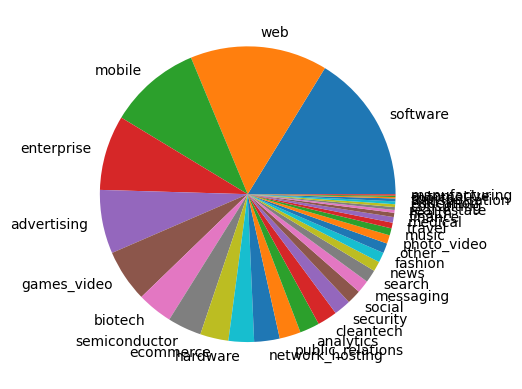

In [41]:
labels = freq_category_code.keys()
sizes = freq_category_code.values
plt.pie(sizes, labels=labels)